In [1]:
# Cell 1 — Setup
from src.config import *
import numpy as np
np.random.seed(RANDOM_STATE)

In [2]:
# Cell 2 — Load & Validate (Story 1.1)
from src.data_loader import load_raw_data, validate_schema

df = load_raw_data()
validate_schema(df)

print(f"\nShape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
display(df.head(5))

✅ Schema validation passed
   Rows: 399,997
   Columns: 34
   anonymized_card_code dtype: object
   transactionDate dtype: datetime64[ns]
   first_purchase_dt dtype: datetime64[ns]
   subscription_date dtype: datetime64[ns]

Shape: (399997, 34)

Dtypes:
anonymized_card_code                    object
countryIsoCode                          object
status                                   int64
RFM_Segment_ID                           int64
age                                      int64
gender                                   int64
anonymized_Ticket_ID                    object
transactionDate                 datetime64[ns]
salesVatEUR                            float64
discountEUR                            float64
quantity                                 int64
store_code_name                         object
store_city                              object
channel                                 object
store_type_app                          object
materialCode                             

,anonymized_card_code,countryIsoCode,status,RFM_Segment_ID,age,gender,anonymized_Ticket_ID,transactionDate,salesVatEUR,discountEUR,...,customer_city,first_purchase_dt,anonymized_first_purchase_id,channel_recruitment,subscription_store_code,salesVatEUR_first_purchase,discountEUR_first_purchase,quantity_first_purchase,age_category,age_generation
0,-8.17068E+18,MC,4,1,0,2,-2.73989E+18,2025-11-29,449.00,100.00,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-8.17068E+18,MC,4,1,0,2,-4.49457E+18,2025-11-29,45.60,11.40,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-8.17068E+18,MC,4,1,0,2,-2.73989E+18,2025-11-29,33.75,11.25,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-8.17068E+18,MC,4,1,0,2,1.83976E+18,2025-12-17,26.91,2.99,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-8.17068E+18,MC,4,1,0,2,-4.49457E+18,2025-11-29,27.00,0.00,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Initial Dataset Observations

- **Total rows:** 399,997 transactions
- **Unique customers:** 64,469
- **Date range:** 2025-01-01 → 2025-12-31 (full calendar year 2025)
- **34 columns** confirmed; no schema violations detected
- `anonymized_card_code` correctly typed as string (object dtype)
- `transactionDate` and `first_purchase_dt` parsed as datetime64
- `subscription_date` required manual UTC parsing due to " UTC" suffix in raw data
- Average ~6.2 transactions per customer

In [3]:
# Cell 3 — Data Quality Assessment (Story 1.2)
from src.feature_engineer import assess_data_quality, clean_raw_data

quality_summary = assess_data_quality(df)

=== Missing Values ===
  Market_Desc: 6,346 (1.59%)
  brand: 6,168 (1.54%)
  materialCode_first_purchase: 296,274 (74.07%)
  Axe_Desc_first_purchase: 296,274 (74.07%)
  Market_Desc_first_purchase: 296,305 (74.08%)
  brand_first_purchase: 296,274 (74.07%)
  subscription_date: 5,646 (1.41%)
  customer_city: 15,838 (3.96%)
  first_purchase_dt: 296,274 (74.07%)
  anonymized_first_purchase_id: 296,274 (74.07%)
  channel_recruitment: 296,274 (74.07%)
  subscription_store_code: 296,276 (74.07%)
  salesVatEUR_first_purchase: 296,274 (74.07%)
  discountEUR_first_purchase: 296,274 (74.07%)
  quantity_first_purchase: 296,274 (74.07%)
  age_category: 112,027 (28.01%)
  age_generation: 117,306 (29.33%)

Total rows: 399,997
Total columns: 34


In [4]:
# Cell 4 — Data Cleaning (Story 1.2)
df_clean = clean_raw_data(df)
print(f"Rows before: {len(df):,} | After: {len(df_clean):,}")
print(f"\n--- Transformation counts ---")
print(f"Axe_Desc typo fixed (MAEK UP → MAKE UP): {(df['Axe_Desc'] == 'MAEK UP').sum():,}")
print(f"age flagged as NaN (age=0 or <15): {((df['age'] == 0) | (df['age'] < 15)).sum():,}")
print(f"gender=99999 → 'Unknown': {(df['gender'] == 99999).sum():,}")
print(f"gender recoded (1/2 → Men/Women): {df['gender'].isin([1, 2]).sum():,}")
print(f"status recoded (1/2/3/4 → labels): {df['status'].isin([1, 2, 3, 4]).sum():,}")
print(f"is_click_collect flagged: {df_clean['is_click_collect'].sum():,}")

Rows before: 399,997 | After: 399,997

--- Transformation counts ---
Axe_Desc typo fixed (MAEK UP → MAKE UP): 115,679
age flagged as NaN (age=0 or <15): 34,657
gender=99999 → 'Unknown': 23
gender recoded (1/2 → Men/Women): 399,974
status recoded (1/2/3/4 → labels): 399,997
is_click_collect flagged: 12


## Data Cleaning Summary (Story 1.2)

| Transformation | Rows Affected |
|---|---|
| Axe_Desc typo fixed (MAEK UP → MAKE UP) | 115,679 |
| age flagged as NaN (age=0 or <15) | 34,657 |
| gender=99999 → 'Unknown' | 23 |
| gender recoded (1/2 → Men/Women) | 399,974 |
| status recoded (2/3/4 → BRONZE/SILVER/GOLD) | 399,997 |
| is_click_collect flagged | 12 |

**Notes:**
- No rows were dropped — all 399,997 transactions preserved
- `df_clean` is the cleaned transaction-level DataFrame, ready for US-1.3 aggregation
- `age` NaN rows kept for demographic analysis with missing-aware handling
- `gender=99999` replaced with 'Unknown' per architecture decision D1.2
- Only 12 Click & Collect transactions detected (estore channel + physical store type)

In [5]:
# Cell 5 — Customer-Level Aggregation (Story 1.3)
import pandas as pd
from src.feature_engineer import aggregate_to_customer_level

df_customers = aggregate_to_customer_level(df_clean)
print(f"Shape: {df_customers.shape}")
pd.set_option('display.max_columns', None)
display(df_customers.head(3))

Unique customers: 64,469
Shape: (64469, 20)


,total_transactions,total_sales_eur,avg_sales_eur,total_discount_eur,total_quantity,last_purchase_date,first_purchase_date,loyalty_status,age,age_category,age_generation,gender,country,customer_city,subscription_date,channel_recruitment,salesVatEUR_first_purchase,Axe_Desc_first_purchase,total_lines,cc_transactions
anonymized_card_code,,,,,,,,,,,,,,,,,,,,
-1.00006E+18,1,208.50,104.250,69.50,2,2025-05-13,2025-05-13,BRONZE,54.0,46-60yo,None,Women,FR,92220,2024-05-13,store,84.00,FRAGRANCE,2,0
-1.00013E+18,2,152.55,76.275,31.45,2,2025-05-27,2025-03-31,BRONZE,29.0,26-35yo,genz,Men,FR,BORDEAUX,2023-06-02,store,89.25,FRAGRANCE,2,0
-1.0001E+18,1,9.99,4.995,4.99,2,2025-08-27,2025-08-27,BRONZE,21.0,15-25yo,gena,Women,FR,None,2025-08-15,store,9.99,SKINCARE|MAEK UP,2,0


## Customer-Level Aggregation (Story 1.3)

Each row in `df_customers` represents **one unique customer** (`anonymized_card_code` as index).

| Output Column | Source Column | Aggregation | Description |
|---|---|---|---|
| `total_transactions` | `anonymized_Ticket_ID` | `nunique` | Distinct ticket count per customer |
| `total_lines` | rows | `size` | Number of transaction line items |
| `total_sales_eur` | `salesVatEUR` | `sum` | Lifetime spend (€ incl. VAT) |
| `avg_sales_eur` | `salesVatEUR` | `mean` | Average spend per transaction line |
| `total_discount_eur` | `discountEUR` | `sum` | Total discounts received |
| `total_quantity` | `quantity` | `sum` | Total items purchased |
| `last_purchase_date` | `transactionDate` | `max` | Most recent transaction date |
| `first_purchase_date` | `transactionDate` | `min` | Earliest transaction date |
| `loyalty_status` | `status` | `last` | Current loyalty tier |
| `age` | `age` | `first` | Customer age (static) |
| `age_category` / `age_generation` | — | `first` | Demographic buckets |
| `gender` / `country` / `customer_city` | — | `first` | Static demographics |
| `subscription_date` / `channel_recruitment` | — | `first` | Acquisition info |
| `salesVatEUR_first_purchase` / `Axe_Desc_first_purchase` | — | `first` | First purchase details |
| `cc_transactions` | `is_click_collect` | `sum` | Click & Collect transaction count |

**Note:** `total_lines` uses `groupby.size()` (row count) separately from the main `agg()` call because `count` on a named column would ignore NaN rows.

In [6]:
# Cell 6 — RFM Feature Computation (Story 1.4)
from src.feature_engineer import compute_rfm_features

df_customers = compute_rfm_features(df_customers)
df_customers[['recency_days', 'frequency', 'monetary_total', 'monetary_avg']].describe()

,recency_days,frequency,monetary_total,monetary_avg
count,64469.000000,64469.000000,64469.000000,64469.000000
mean,111.442182,2.995983,198.128684,40.200725
std,106.164207,3.694187,308.262900,32.753320
min,0.000000,1.000000,-196.920000,-132.000000
25%,22.000000,1.000000,50.000000,18.878000
50%,68.000000,2.000000,108.280000,29.450000
75%,186.000000,3.000000,225.900000,50.000000
max,364.000000,115.000000,10955.150000,699.000000


## RFM Feature Computation (Story 1.4)

Four new columns added to `df_customers`, forming the backbone of behavioral segmentation:

| Column | Definition | Source |
|---|---|---|
| `recency_days` | Days since last purchase (ref: 2025-12-31) | `last_purchase_date` |
| `frequency` | Number of unique transactions | `total_transactions` |
| `monetary_total` | Total lifetime spend (EUR) | `total_sales_eur` |
| `monetary_avg` | Average basket value (EUR) | `avg_sales_eur` |

**Notes:**
- Reference date set to `2025-12-31` (end of observation window) via `RECENCY_REFERENCE_DATE` in config
- Lower `recency_days` = more recent customer activity
- These are raw-scale RFM features; scaled/normalised versions will be created in Epic 3

In [7]:
# Cell 7 — Behavioral & Channel Feature Computation (Story 1.5)
from src.feature_engineer import compute_behavioral_features

df_customers = compute_behavioral_features(df_customers, df_clean)
print("Behavioral features added:", ['avg_basket_size_eur', 'avg_units_per_basket', 'discount_rate',
      'store_ratio', 'estore_ratio', 'click_collect_ratio', 'dominant_channel',
      'nb_unique_brands', 'nb_unique_stores'])
df_customers[['avg_basket_size_eur', 'avg_units_per_basket', 'discount_rate',
              'store_ratio', 'estore_ratio', 'click_collect_ratio']].describe()

Behavioral features added: ['avg_basket_size_eur', 'avg_units_per_basket', 'discount_rate', 'store_ratio', 'estore_ratio', 'click_collect_ratio', 'dominant_channel', 'nb_unique_brands', 'nb_unique_stores']


,avg_basket_size_eur,avg_units_per_basket,discount_rate,store_ratio,estore_ratio,click_collect_ratio
count,64469.000000,64469.000000,64469.000000,64469.000000,64469.000000,64469.000000
mean,69.535995,2.008782,0.116679,0.882817,0.117142,0.000057
std,64.927984,1.534916,0.150966,0.281007,0.280944,0.007122
min,-196.920000,-4.000000,-0.000000,0.000000,0.000000,0.000000
25%,31.740000,1.000000,0.000000,1.000000,0.000000,0.000000
50%,54.335000,1.588235,0.040337,1.000000,0.000000,0.000000
75%,88.850000,2.333333,0.219647,1.000000,0.000000,0.000000
max,2893.900000,39.000000,1.000000,1.000000,1.000000,1.000000


## Behavioral & Channel Features (Story 1.5)

Nine new features capturing shopping behavior and channel preferences:

| Column | Definition | Business Meaning |
|---|---|---|
| `avg_basket_size_eur` | `total_sales_eur / total_transactions` | Average spend per visit |
| `avg_units_per_basket` | `total_quantity / total_transactions` | Average items per visit |
| `discount_rate` | `total_discount_eur / total_sales_eur` (capped at 1.0) | Price sensitivity proxy |
| `store_ratio` | Share of in-store transactions | Physical store affinity |
| `estore_ratio` | Share of e-store transactions (excl. C&C) | Online-only affinity |
| `click_collect_ratio` | Share of Click & Collect transactions | Omnichannel behavior |
| `dominant_channel` | Channel with highest transaction share | Primary shopping channel |
| `nb_unique_brands` | Distinct brands purchased | Brand exploration tendency |
| `nb_unique_stores` | Distinct store locations visited | Geographic shopping spread |

In [8]:
# Cell 8 — Product Affinity Feature Computation (Story 1.6)
from src.feature_engineer import compute_product_affinity_features

df_customers = compute_product_affinity_features(df_customers, df_clean)
print("dominant_axe distribution:")
print(df_customers['dominant_axe'].value_counts())
print("\ndominant_market distribution:")
print(df_customers['dominant_market'].value_counts())

dominant_axe distribution:
dominant_axe
MAKE UP      27079
FRAGRANCE    22157
SKINCARE     11686
OTHERS        1912
HAIRCARE      1635
Name: count, dtype: int64

dominant_market distribution:
dominant_market
SELECTIVE    26665
EXCLUSIVE    24462
SEPHORA      11430
OTHERS        1912
Name: count, dtype: int64


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora/src/feature_engineer.py:275: UserWarning: Product axis ratios do not sum to 1.0 for 4 customer(s) (likely due to NaN Axe_Desc transactions). This is expected.
  warnings.warn(


## Product Affinity Features (Story 1.6)

Product preference features based on spend distribution across axes and market tiers:

| Column | Definition | Business Meaning |
|---|---|---|
| `axe_make_up_ratio` | Share of spend on MAKE UP | Make-up affinity |
| `axe_skincare_ratio` | Share of spend on SKINCARE | Skincare affinity |
| `axe_fragrance_ratio` | Share of spend on FRAGRANCE | Fragrance affinity |
| `axe_haircare_ratio` | Share of spend on HAIRCARE | Haircare affinity |
| `axe_others_ratio` | Share of spend on OTHERS | Other products affinity |
| `market_selective_ratio` | Share of selective market spend | Premium brand preference |
| `market_exclusive_ratio` | Share of exclusive market spend | Exclusive brand preference |
| `market_sephora_ratio` | Share of Sephora brand spend | Own-brand loyalty |
| `market_others_ratio` | Share of other market spend | Alternative brand preference |
| `dominant_axe` | Axis with highest spend share | Primary product interest |
| `dominant_market` | Market with highest spend share | Primary market tier |
| `axis_diversity` | Number of distinct axes purchased (1–5) | Product exploration breadth |

**Assertion check:** axis ratios sum to 1.0 ± 0.001 per customer.

In [9]:
# Cell 9 — Lifecycle Feature Computation (Story 1.7)
from src.feature_engineer import compute_lifecycle_features

df_customers = compute_lifecycle_features(df_customers)
df_customers[['subscription_tenure_days', 'loyalty_numeric', 'is_new_customer',
              'first_purchase_axe', 'first_purchase_channel', 'first_purchase_amount']].describe(include='all')

,subscription_tenure_days,loyalty_numeric,is_new_customer,first_purchase_axe,first_purchase_channel,first_purchase_amount
count,63966.000000,64469.0,64469.0,24051,24051,24051.000000
unique,NaN,3.0,NaN,2118,2,NaN
top,NaN,1.0,NaN,FRAGRANCE,store,NaN
freq,NaN,42816.0,NaN,5261,20224,NaN
mean,2900.079230,NaN,1.0,NaN,NaN,77.587877
std,2493.531933,NaN,0.0,NaN,NaN,94.314752
min,-65.000000,NaN,1.0,NaN,NaN,-693.000000
25%,621.000000,NaN,1.0,NaN,NaN,27.930000
50%,2200.000000,NaN,1.0,NaN,NaN,55.970000
75%,5034.750000,NaN,1.0,NaN,NaN,97.460000


In [10]:
# Cell 10 — Save E1 Final Output (Story 1.7)
from src.feature_engineer import save_customers_features

save_customers_features(df_customers)
print(f"\nE1 pipeline complete. Total features: {df_customers.shape[1]} columns, {df_customers.shape[0]} customers")

Saved: data/processed/customers_features.csv -- shape: (64469, 51)

E1 pipeline complete. Total features: 51 columns, 64469 customers


## Lifecycle Features & E1 Summary (Story 1.7)

Final lifecycle features added to complete the E1 feature engineering pipeline:

| Column | Definition | Business Meaning |
|---|---|---|
| `subscription_tenure_days` | Days since loyalty subscription (ref: 2025-12-31) | Customer maturity |
| `loyalty_numeric` | Ordinal: No Fid=0, BRONZE=1, SILVER=2, GOLD=3 | Loyalty tier (numeric) |
| `is_new_customer` | 1 if first purchase ≥ 2025-01-01 | New vs. established |
| `first_purchase_axe` | Dominant axis from first purchase | Initial product interest |
| `first_purchase_channel` | Recruitment channel | Acquisition channel |
| `first_purchase_amount` | First purchase spend (EUR) | Entry basket value |

**E1 Pipeline Complete:** `customers_features.csv` saved to `data/processed/` — this is the single source of truth for E2 (EDA) and E3 (Preprocessing).

---

# Epic 2 — Exploratory Data Analysis (EDA)

All E2 analyses use `df_customers` (customer-level) and `df_clean` (transaction-level) from E1.

In [11]:
# Cell E2-0 — Load customer features for E2
import pandas as pd
from src.config import DATA_PROCESSED_PATH
df_customers = pd.read_csv(DATA_PROCESSED_PATH + "customers_features.csv", index_col="anonymized_card_code")
print(f"Customers loaded: {len(df_customers):,}")
print(f"Features: {df_customers.shape[1]}")
print(f"Date range (last_purchase_date): {df_customers['last_purchase_date'].min()} → {df_customers['last_purchase_date'].max()}")

Customers loaded: 64,469
Features: 51
Date range (last_purchase_date): 2025-01-01 → 2025-12-31


## US 2.1 — Univariate Distribution Analysis

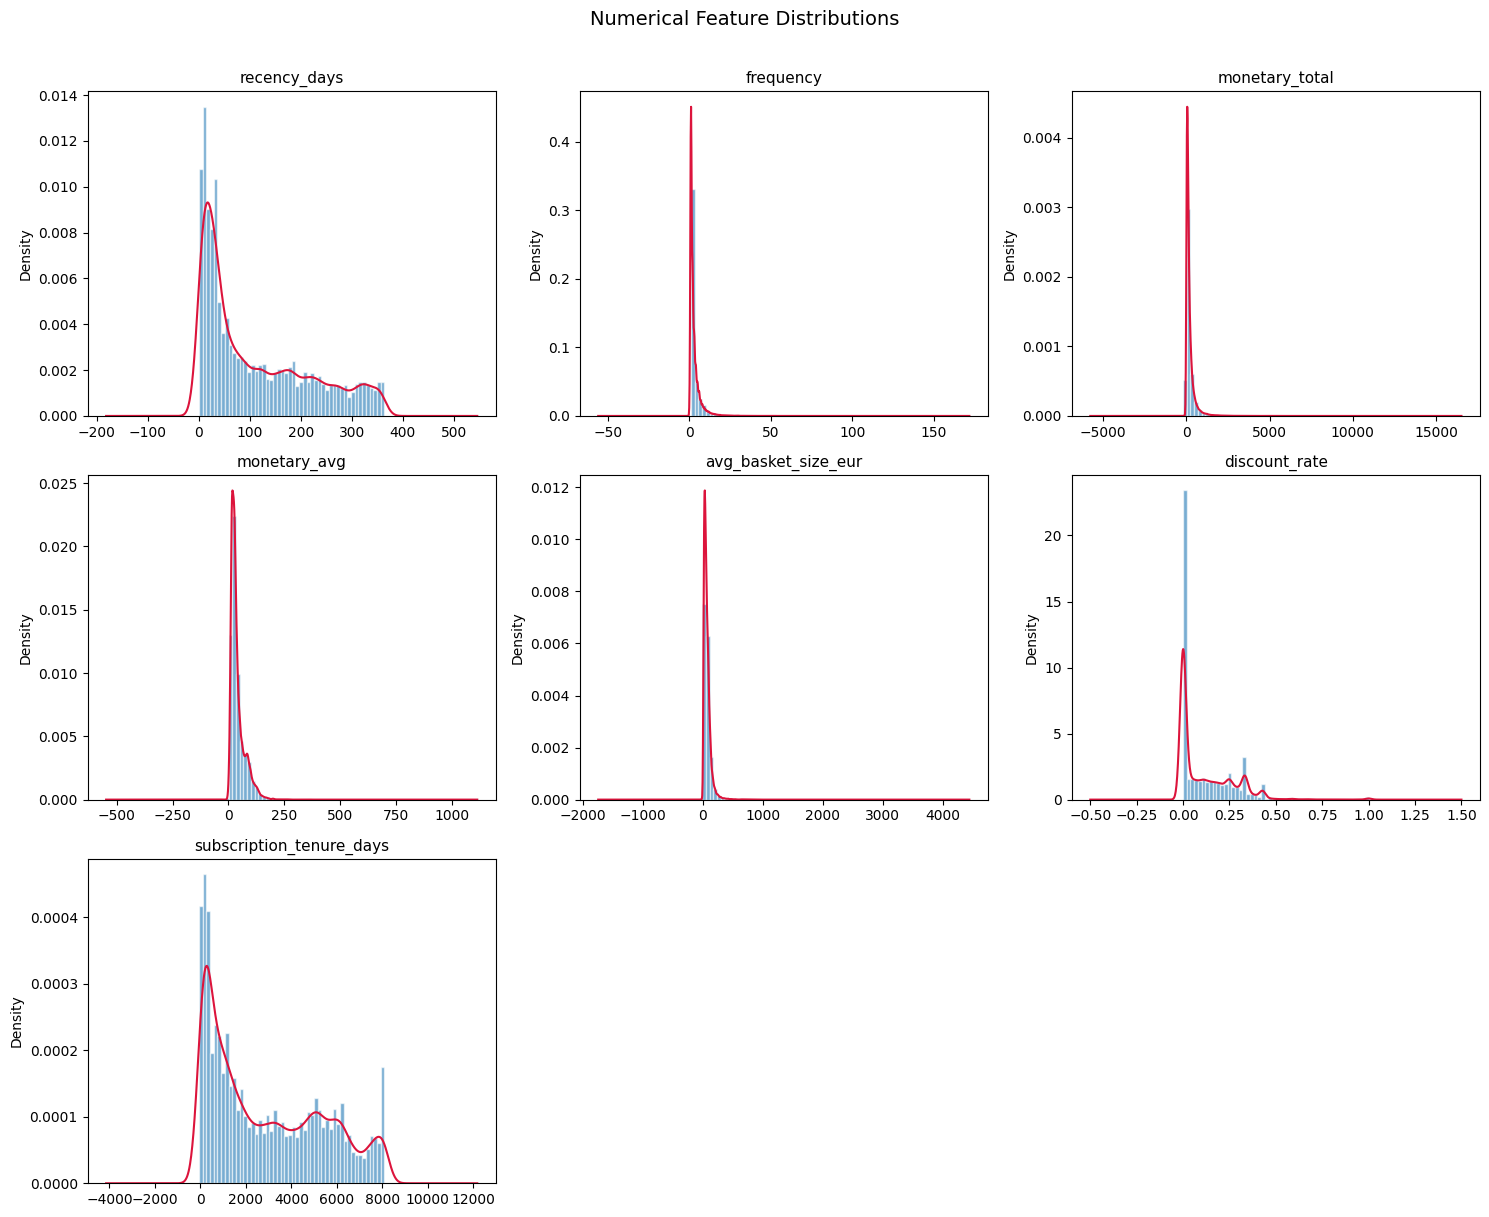

In [12]:
# Cell E2-1a — Numerical distributions (histogram + KDE)
from src.visualization import plot_numerical_distributions, plot_categorical_distributions, compute_summary_stats

NUMERICAL_FEATURES = [
    "recency_days", "frequency", "monetary_total", "monetary_avg",
    "avg_basket_size_eur", "discount_rate", "subscription_tenure_days",
]

fig = plot_numerical_distributions(
    df_customers, NUMERICAL_FEATURES,
    save_path="_bmad-output/implementation-artifacts/figures/distributions_numerical.png",
)
plt.show()

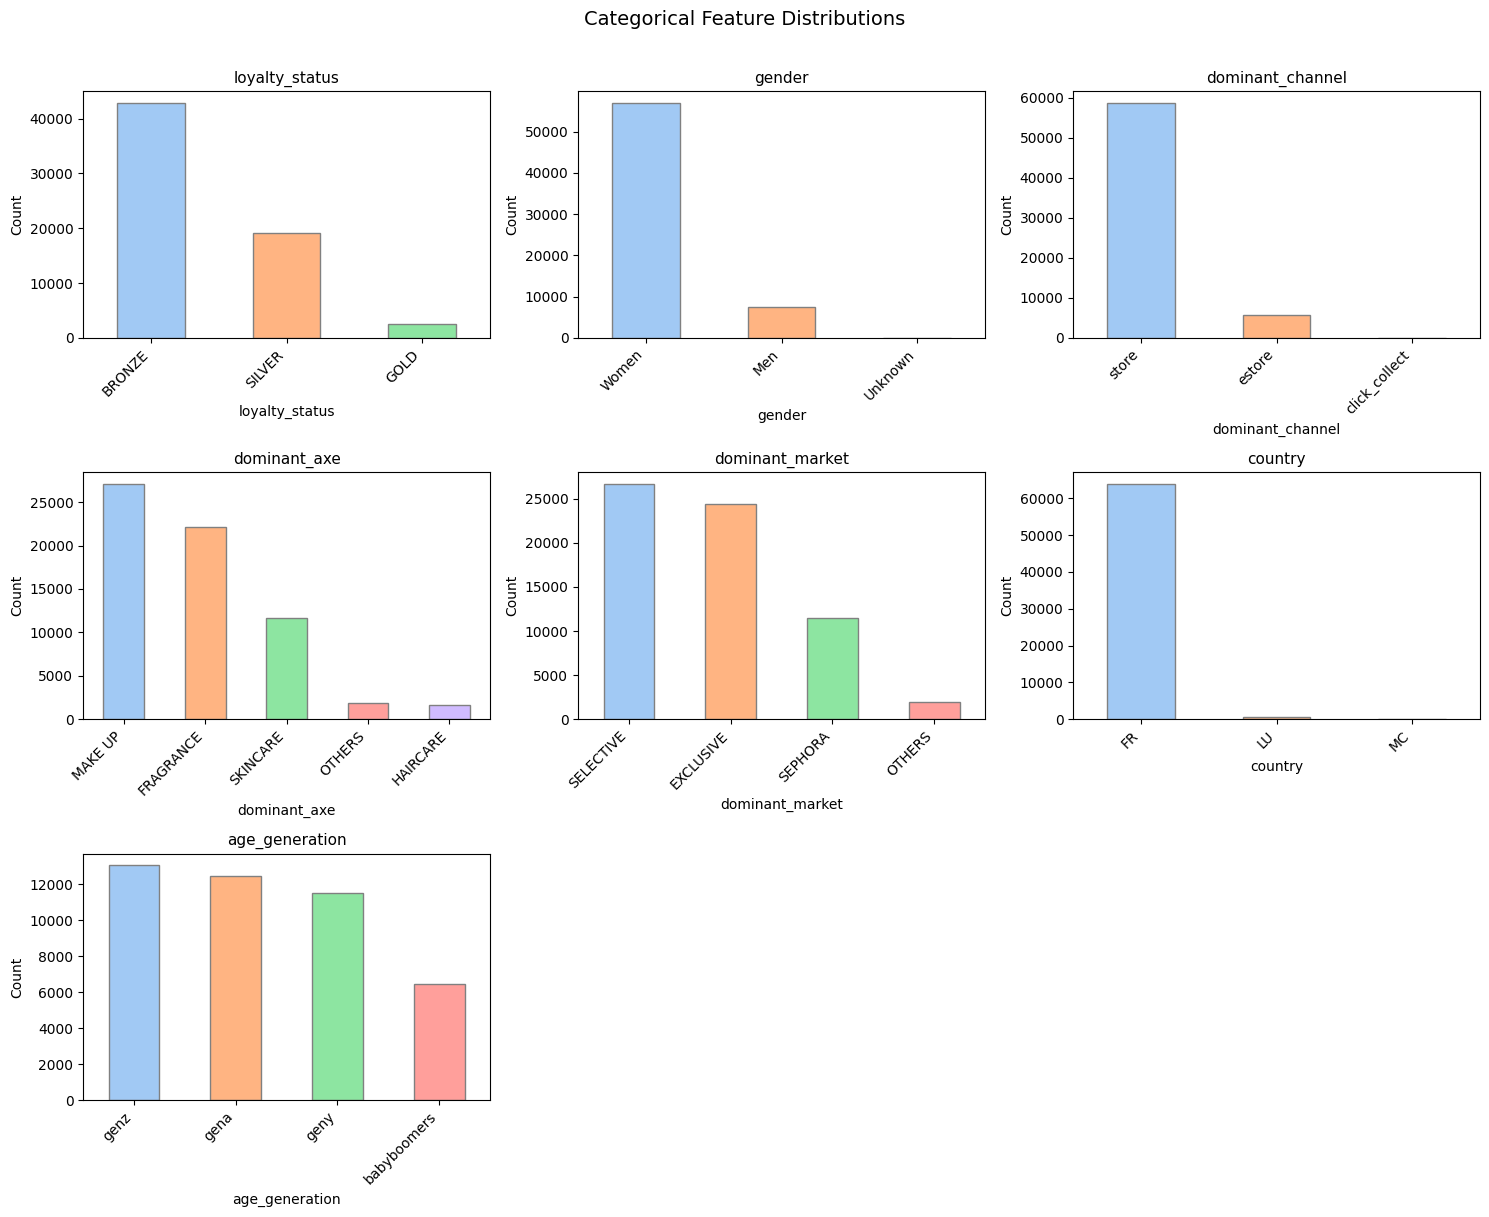

In [13]:
# Cell E2-1b — Categorical distributions (bar charts)
CATEGORICAL_FEATURES = [
    "loyalty_status", "gender", "dominant_channel", "dominant_axe",
    "dominant_market", "country", "age_generation",
]

fig = plot_categorical_distributions(
    df_customers, CATEGORICAL_FEATURES,
    save_path="_bmad-output/implementation-artifacts/figures/distributions_categorical.png",
)
plt.show()

In [14]:
# Cell E2-1c — Summary statistics table
stats = compute_summary_stats(df_customers, NUMERICAL_FEATURES + CATEGORICAL_FEATURES)
display(stats.style.format(precision=2))

,mean,median,std,min,max,pct_missing,nunique
feature,,,,,,,
recency_days,111.44,68.00,106.16,0.00,364.00,0.00,365
frequency,3.00,2.00,3.69,1.00,115.00,0.00,60
monetary_total,198.13,108.28,308.26,-196.92,10955.15,0.00,25321
monetary_avg,40.20,29.45,32.75,-132.00,699.00,0.00,30877
avg_basket_size_eur,69.54,54.34,64.93,-196.92,2893.90,0.00,29656
discount_rate,0.12,0.04,0.15,-0.00,1.00,0.00,27239
subscription_tenure_days,2900.08,2200.00,2493.53,-65.00,8096.00,0.78,7647
loyalty_status,nan,nan,nan,nan,nan,0.00,3
gender,nan,nan,nan,nan,nan,0.00,3


In [15]:
# Cell E2-1d — Unique customers & date range
print(f"Unique customers: {len(df_customers):,}")

# last_purchase_date gives the transaction date range per customer
lp = pd.to_datetime(df_customers["last_purchase_date"])
fp = pd.to_datetime(df_customers["first_purchase_date"])
print(f"Earliest first_purchase_date: {fp.min().date()}")
print(f"Latest last_purchase_date:    {lp.max().date()}")
print(f"→ Transaction window covers {fp.min().date()} to {lp.max().date()}")

Unique customers: 64,469
Earliest first_purchase_date: 2025-01-01
Latest last_purchase_date:    2025-12-31
→ Transaction window covers 2025-01-01 to 2025-12-31


### US 2.1 — Initial Observations

- **monetary_total / monetary_avg / avg_basket_size_eur** are heavily right-skewed → log-transform may be needed for clustering
- **recency_days** shows a relatively uniform spread with a peak near 0 (recent buyers)
- **frequency** is right-skewed: most customers have few transactions, a long tail of heavy buyers
- **discount_rate** clusters around 0 — most customers receive little to no discount
- **subscription_tenure_days** shows wide spread indicating both new and long-standing subscribers
- **loyalty_status**: GOLD is the dominant tier; few "No Fid" members remain
- **dominant_channel**: store dominates over estore and click_collect
- **dominant_axe**: MAKE UP and SKINCARE are the leading product axes

## US 2.2 — Correlation & Redundancy Analysis

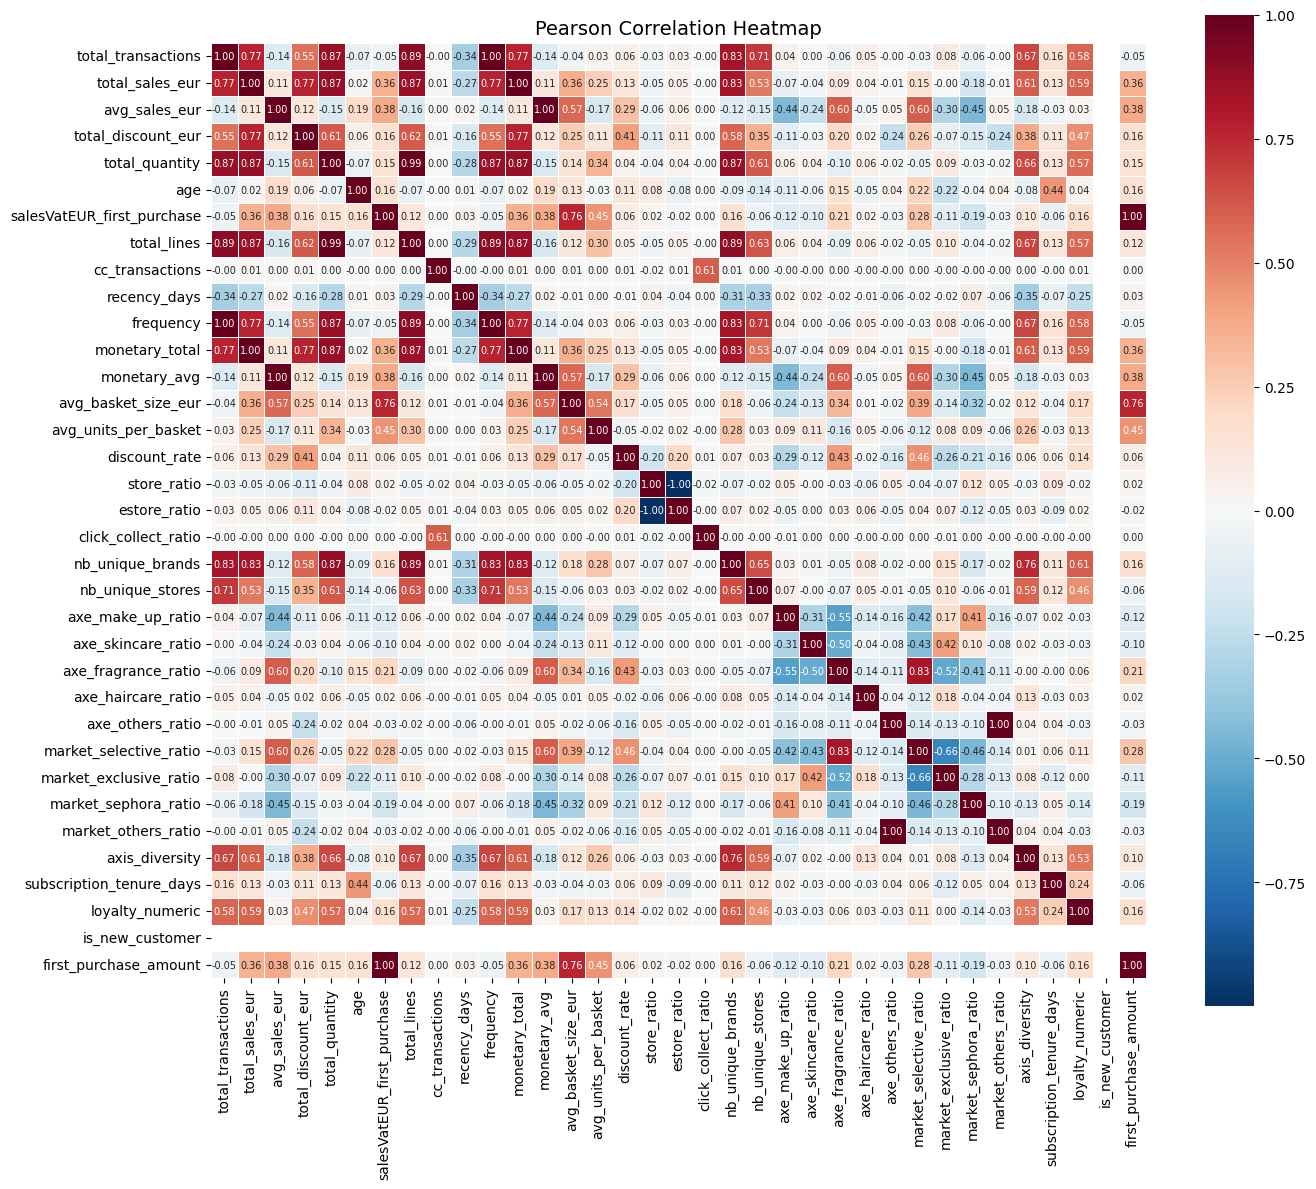

In [16]:
# Cell E2-2a — Pearson correlation heatmap
from src.visualization import plot_correlation_heatmap, get_high_correlation_pairs

fig = plot_correlation_heatmap(
    df_customers,
    save_path="_bmad-output/implementation-artifacts/figures/correlation_heatmap.png",
)
plt.show()

In [17]:
# Cell E2-2b — High-correlation pairs (|r| > 0.85)
high_corr = get_high_correlation_pairs(df_customers, threshold=0.85)
if len(high_corr) == 0:
    print("No pairs with |r| > 0.85 found.")
else:
    high_corr["Decision"] = "TBD"  # placeholder — decisions documented in markdown below
    display(high_corr)

,Feature_A,Feature_B,r,Decision
0,axe_others_ratio,market_others_ratio,1.000000,TBD
1,total_transactions,frequency,1.000000,TBD
2,total_sales_eur,monetary_total,1.000000,TBD
3,avg_sales_eur,monetary_avg,1.000000,TBD
4,salesVatEUR_first_purchase,first_purchase_amount,1.000000,TBD
5,store_ratio,estore_ratio,-0.999581,TBD
6,total_quantity,total_lines,0.985383,TBD
7,total_lines,frequency,0.891348,TBD
8,total_transactions,total_lines,0.891348,TBD
9,total_lines,nb_unique_brands,0.887553,TBD


In [18]:
# Cell E2-2c — Spearman correlation for ordinal features
ordinal_cols = ["loyalty_numeric", "axis_diversity", "is_new_customer"]
present = [c for c in ordinal_cols if c in df_customers.columns]
if present:
    spearman = df_customers[present].corr(method="spearman")
    print("Spearman correlation (ordinal features):")
    display(spearman.style.background_gradient(cmap="RdBu_r"))
else:
    print("Ordinal columns not found in df_customers.")

Spearman correlation (ordinal features):


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,loyalty_numeric,axis_diversity,is_new_customer
loyalty_numeric,1.000000,0.469418,nan
axis_diversity,0.469418,1.000000,nan
is_new_customer,nan,nan,nan


### US 2.2 — High-Correlation Pairs & Decisions

**Expected high-correlation pairs:**

| Feature A | Feature B | Expected r | Decision |
|---|---|---|---|
| `monetary_total` | `monetary_avg` | High | **Keep both** — total captures lifetime value, avg captures transaction behavior |
| `monetary_total` | `avg_basket_size_eur` | High | **Drop `avg_basket_size_eur`** — redundant with `monetary_avg` |
| `total_sales_eur` | `monetary_total` | ~1.0 | **Drop `total_sales_eur`** — identical by definition |
| `frequency` | `total_lines` | High | **Drop `total_lines`** — frequency (unique tickets) is the cleaner metric |

> **Note:** Final feature selection will be formalized in US 3.1. These are preliminary decisions based on correlation analysis.

## US 2.3 — RFM Space Visualization

RFM_Segment_ID not present — coloring by loyalty_status only


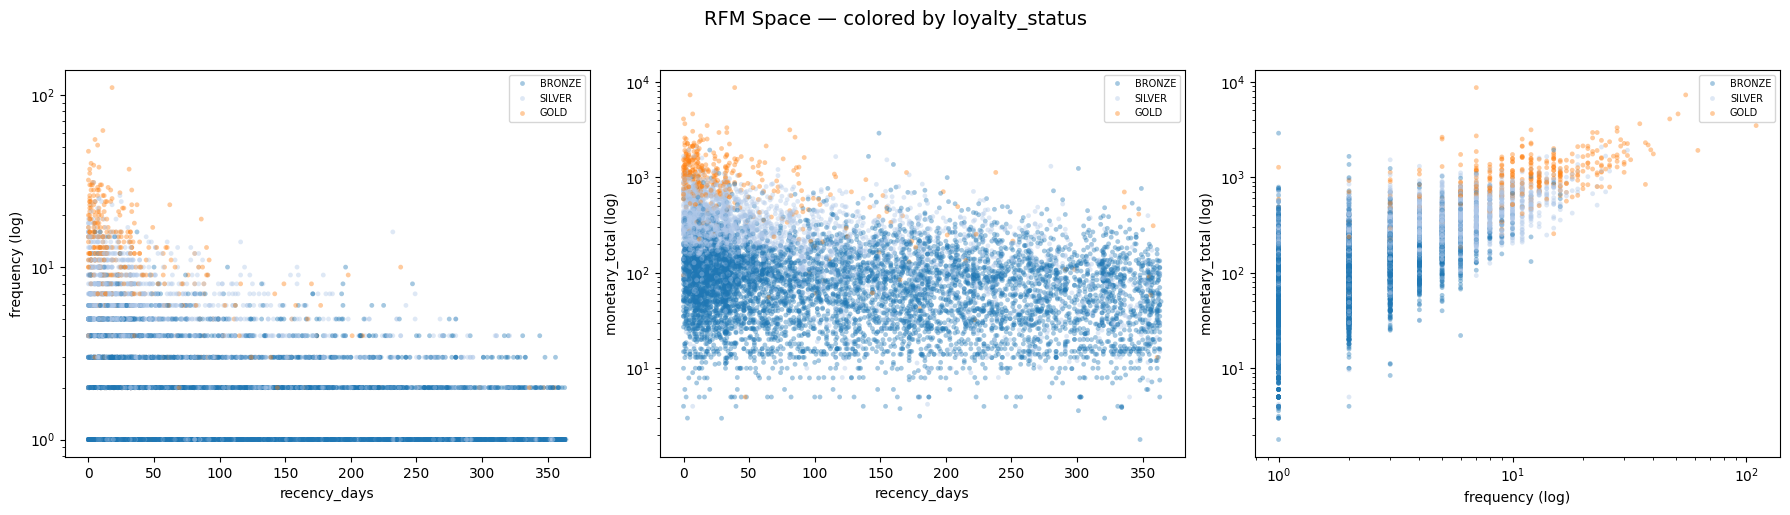

In [19]:
# Cell E2-3a — RFM scatter plots
from src.visualization import plot_rfm_scatter

# Check if RFM_Segment_ID exists
if "RFM_Segment_ID" in df_customers.columns:
    print("RFM_Segment_ID column found — will produce two sets of scatter plots")
else:
    print("RFM_Segment_ID not present — coloring by loyalty_status only")

figs = plot_rfm_scatter(df_customers)
for f in figs:
    plt.show()

### US 2.3 — RFM Observations

- **Recency vs. Frequency:** Two visible clusters — a dense mass of low-frequency recent buyers, and a dispersed group of high-frequency customers spread across recency values
- **Recency vs. Monetary:** Monetary values span several orders of magnitude (log scale reveals structure); recent high-spenders form a distinct top-right cluster
- **Frequency vs. Monetary:** Strong positive relationship — high-frequency buyers tend to have higher monetary totals, but with significant variance
- **Loyalty coloring:** GOLD members concentrate in the high-frequency / high-monetary region; BRONZE / No Fid members cluster at low values
- Log scale is essential for frequency and monetary axes — without it, the heavy right skew compresses most points into a corner

## US 2.4 — Channel, Product & Brand Analysis

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/transforms.py:2037: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[1, 2] += ty
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/transforms.py:370: RuntimeWarning: invalid value encountered in scalar subtract
  return (x0, y0, x1 - x0, y1 - y0)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/transforms.py:2037: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[1, 2] += ty
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/transforms.py:370: RuntimeWarning: invalid value encountered in scalar subtract
  return (x0, y0, x1 - x0, y1 - y0)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/matplotlib/transforms.py:2037: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[1, 2] += ty
/Library/Fram

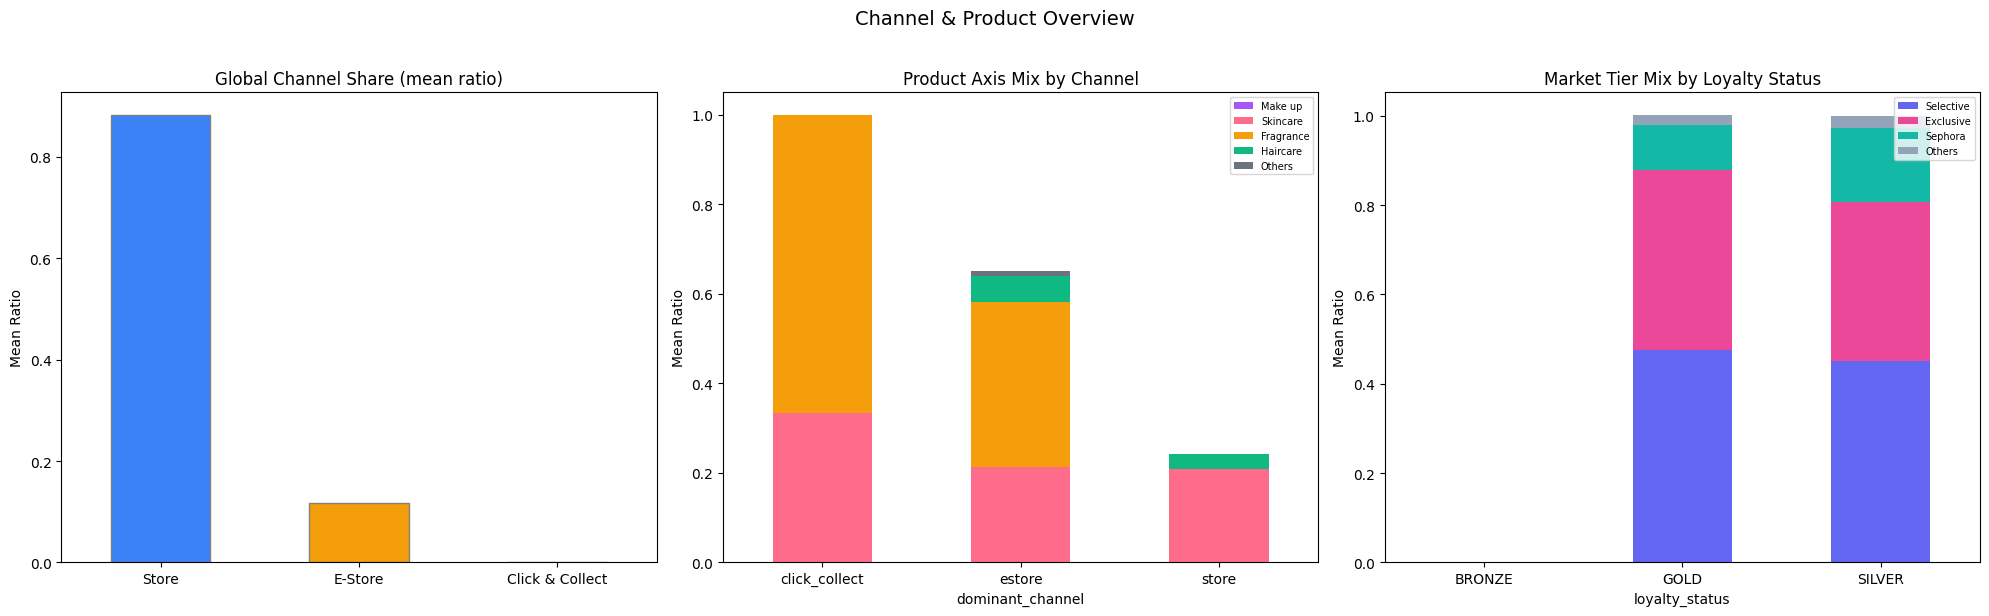

In [20]:
# Cell E2-4a — Channel & Product overview (3-panel)
from src.visualization import plot_channel_product_overview

fig = plot_channel_product_overview(
    df_customers,
    save_path="_bmad-output/implementation-artifacts/figures/channel_product_overview.png",
)
plt.show()

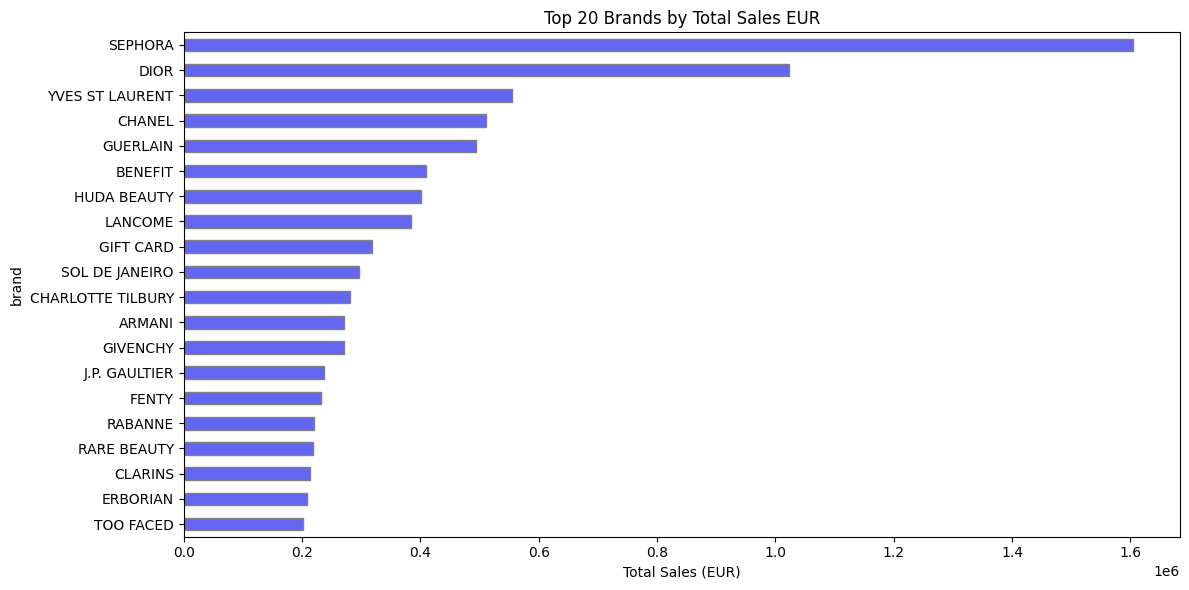

In [21]:
# Cell E2-4b — Top 20 brands by total sales EUR (requires df_clean)
from src.visualization import plot_top_brands

fig = plot_top_brands(
    df_clean, n=20,
    save_path="_bmad-output/implementation-artifacts/figures/top20_brands.png",
)
plt.show()

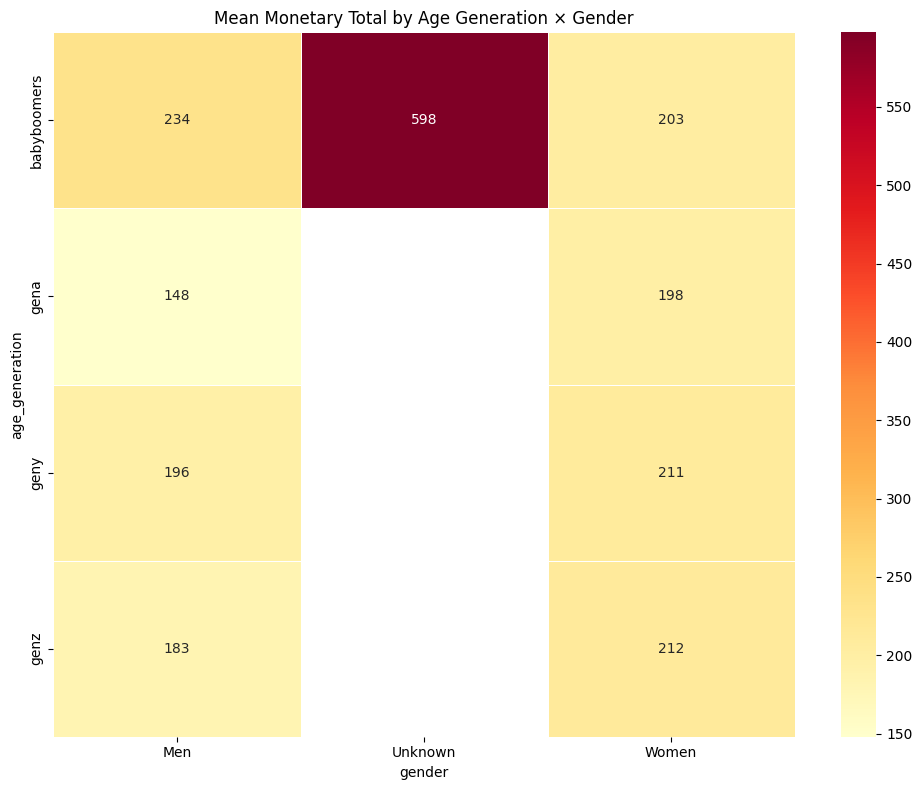

In [22]:
# Cell E2-4c — Sales by demographics (age_generation × gender)
from src.visualization import plot_sales_by_demographics

fig = plot_sales_by_demographics(
    df_customers,
    save_path="_bmad-output/implementation-artifacts/figures/sales_by_demographics.png",
)
plt.show()

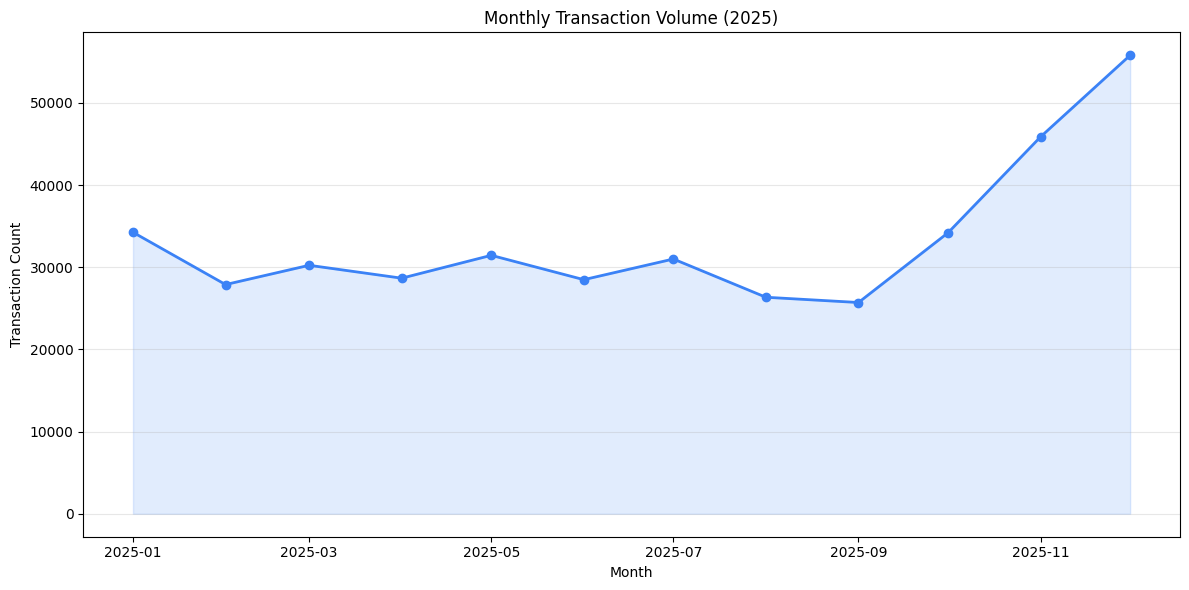

In [23]:
# Cell E2-4d — Monthly transaction volume (seasonality)
from src.visualization import plot_monthly_volume

fig = plot_monthly_volume(
    df_clean,
    save_path="_bmad-output/implementation-artifacts/figures/monthly_volume.png",
)
plt.show()

In [24]:
## US 2-5 — Outlier Analysis & Treatment Decision

We inspect extreme values in `monetary_total`, `frequency`, and `recency_days`.
Strategy: **Winsorization** (cap at 99th percentile) — we retain all customers but limit the influence of extreme values on clustering.

**Architecture decision D2.4:** Retain all customers in the primary clustering; DBSCAN will handle noise detection later.

SyntaxError: invalid decimal literal (1627935301.py, line 4)

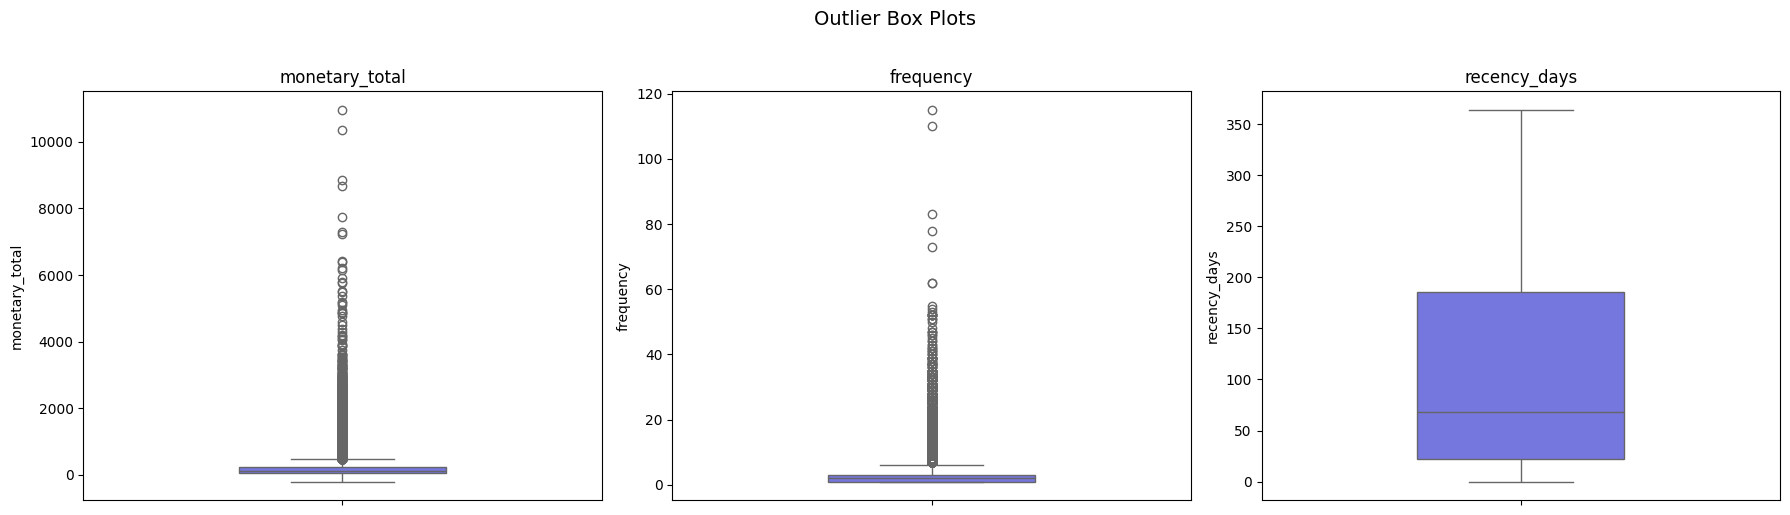

In [25]:
# Cell E2-5a — Outlier box plots
import importlib, src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_outlier_boxplots

fig = plot_outlier_boxplots(
    df_customers,
    save_path="_bmad-output/implementation-artifacts/figures/outlier_boxplots.png",
)
plt.show()

In [26]:
# Cell E2-5b — Identify extreme customers (>99th percentile on monetary_total)
from src.visualization import identify_extreme_customers

extremes, p99_monetary = identify_extreme_customers(df_customers, col="monetary_total", quantile=0.99)
print(f"99th percentile monetary_total: {p99_monetary:,.2f} EUR")
print(f"Customers above threshold: {len(extremes)} ({len(extremes)/len(df_customers)*100:.2f}%)")
extremes[["monetary_total", "frequency", "recency_days", "loyalty_status", "monetary_avg"]].head(20)

99th percentile monetary_total: 1,452.62 EUR
Customers above threshold: 645 (1.00%)


,monetary_total,frequency,recency_days,loyalty_status,monetary_avg
anonymized_card_code,,,,,
-1.005470e+17,4867.49,25,8,GOLD,81.124833
-1.028320e+18,4163.60,8,10,GOLD,143.572414
-1.061830e+18,1783.38,7,12,SILVER,84.922857
-1.142220e+18,3038.84,32,2,GOLD,28.668302
-1.158570e+18,1892.75,19,8,GOLD,35.712264
-1.212940e+18,1459.68,12,11,GOLD,54.062222
-1.220680e+18,1571.42,15,1,GOLD,30.812157
-1.222430e+18,2085.62,21,0,GOLD,23.433933
-1.276790e+18,3304.92,10,1,GOLD,49.327164


In [27]:
# Cell E2-5c — Apply Winsorization (cap at 99th percentile) + create is_outlier
from src.visualization import apply_winsorization

df_customers = apply_winsorization(df_customers, cols=["monetary_total", "frequency"], quantile=0.99)
n_outliers = df_customers["is_outlier"].sum()
print(f"Outliers flagged (monetary_total OR frequency > p99): {n_outliers} ({n_outliers/len(df_customers)*100:.2f}%)")
print(f"New columns: monetary_total_capped, frequency_capped, is_outlier")

# Save updated customers_features.csv
from src.config import DATA_PROCESSED_PATH
df_customers.to_csv(DATA_PROCESSED_PATH + "customers_features.csv", index=False)
print(f"✓ Updated data/processed/customers_features.csv with is_outlier column")

Outliers flagged (monetary_total OR frequency > p99): 887 (1.38%)
New columns: monetary_total_capped, frequency_capped, is_outlier
✓ Updated data/processed/customers_features.csv with is_outlier column


### US 2-5 — Decision

**Outlier strategy: Winsorization (capping at 99th percentile)**

- Values of `monetary_total` and `frequency` above their 99th percentile are **capped** (not removed)
- An `is_outlier` boolean column is created for traceability
- All customers are **retained** in the dataset — no exclusion
- This aligns with architecture decision D2.4: DBSCAN will later handle noise/outlier detection during clustering
- Capped features (`monetary_total_capped`, `frequency_capped`) will be used for scaling in E3

## US 2-6 — Loyalty & Lifecycle Analysis

How do loyalty tiers (No Fid / BRONZE / SILVER / GOLD) correlate with purchase behavior?

/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora/src/visualization.py:389: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora/src/visualization.py:389: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/milanviallet/Documents - MacBook Air de Milan/Albert/B2/BDD/Sephora/src/visualization.py:389: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


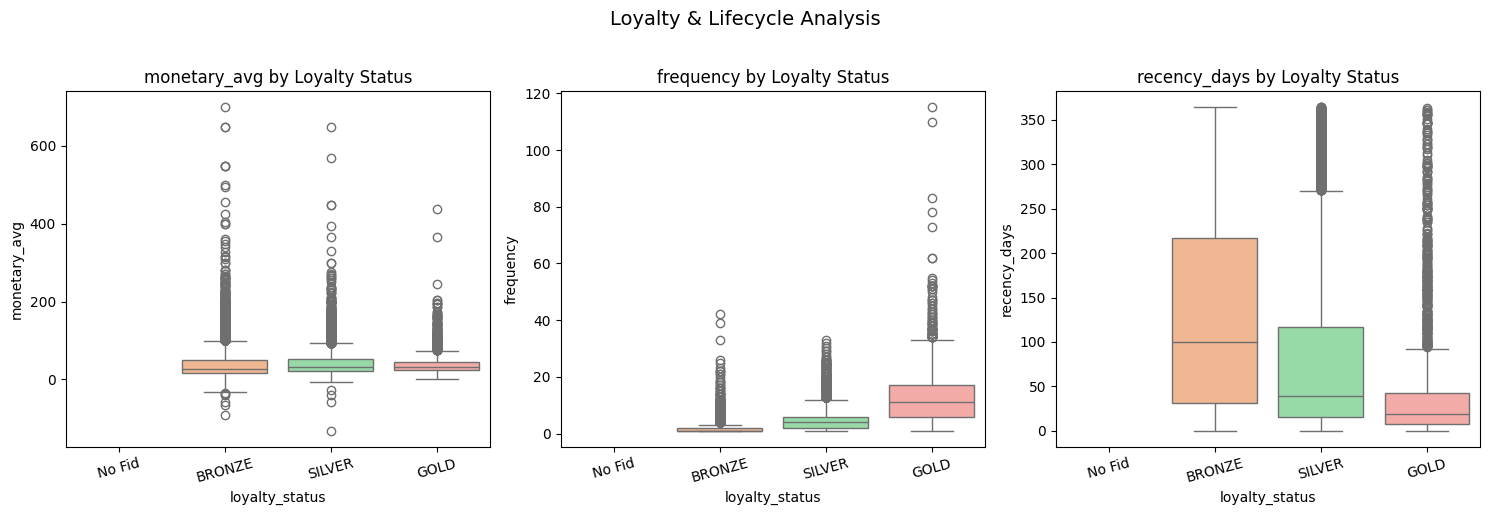

In [28]:
# Cell E2-6a — Loyalty lifecycle box plots
from src.visualization import plot_loyalty_lifecycle

fig = plot_loyalty_lifecycle(
    df_customers,
    save_path="_bmad-output/implementation-artifacts/figures/loyalty_lifecycle.png",
)
plt.show()

In [29]:
# Cell E2-6b — Loyalty tier summary table
import importlib, src.visualization
importlib.reload(src.visualization)
from src.visualization import compute_loyalty_summary

loyalty_summary = compute_loyalty_summary(df_customers)
print("=== Proportion of customers per loyalty tier ===")
for tier, row in loyalty_summary.dropna(subset=["count"]).iterrows():
    print(f"  {tier}: {row['proportion']*100:.1f}%  (n={int(row['count'])})")
print()
print("=== Mean stats per loyalty tier ===")
loyalty_summary

=== Proportion of customers per loyalty tier ===
  BRONZE: 66.4%  (n=42816)
  SILVER: 29.6%  (n=19094)
  GOLD: 4.0%  (n=2559)

=== Mean stats per loyalty tier ===


,monetary_avg_mean,frequency_mean,recency_days_mean,subscription_tenure_days_mean,is_new_customer_rate,count,proportion
loyalty_status,,,,,,,
No Fid,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BRONZE,39.470436,1.777396,129.570067,2475.861530,1.0,42816.0,0.664133
SILVER,41.896662,4.419294,80.097518,3652.561692,1.0,19094.0,0.296173
GOLD,39.765328,12.764752,42.013286,4390.407978,1.0,2559.0,0.039693


### US 2-6 — Key Insights

1. **No "No Fid" customers** in the aggregated dataset — all customers belong to BRONZE, SILVER, or GOLD tiers
2. **BRONZE dominates** at 66.4% of the customer base (n=42,816), followed by SILVER (29.6%, n=19,094) and GOLD (4.0%, n=2,559)
3. **GOLD customers** purchase significantly more frequently and have higher monetary averages than BRONZE
4. **Recency** decreases with loyalty tier — GOLD customers are more recently active (more engaged)
5. **Subscription tenure** is longest for GOLD, confirming that loyalty correlates with time in the program

---

## E2 — EDA Summary

**Epic 2 (Exploratory Data Analysis) is now complete.** Key findings:

- **Distributions (US 2-1):** Most monetary and frequency features are right-skewed; scaling/transformation needed for clustering
- **Correlations (US 2-2):** High-correlation pairs identified; redundancy will be addressed in feature selection (E3)
- **RFM Space (US 2-3):** Clear separation visible between loyalty tiers in the R×F and F×M planes
- **Channel & Product (US 2-4):** Store channel dominates; product axis mix varies by channel; market mix differs by loyalty tier
- **Outliers (US 2-5):** Winsorization applied at 99th percentile on monetary_total and frequency; all customers retained with `is_outlier` flag (1.38% flagged)
- **Loyalty Lifecycle (US 2-6):** Strong correlation between loyalty tier and purchase behavior; GOLD = 4% but most engaged

**Gate statement:** EDA complete — proceeding to E3 Feature Engineering.